In [11]:
# Cell 1: Configure Noisy Drone RF v2 VGG full-complex spectrogram evaluation
import hashlib
import json
import math
import os
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import torch
import yaml
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model

notebook_dir = Path().resolve()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
elif (notebook_dir / 'notebooks').exists() and (notebook_dir / 'src').exists():
    project_root = notebook_dir
elif (notebook_dir / 'ML-wireless-signal-classification').exists():
    project_root = notebook_dir / 'ML-wireless-signal-classification'
else:
    project_root = notebook_dir

cfg_path = project_root / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    local_cfg = yaml.safe_load(cfg_path.read_text())
    dcfg = local_cfg.get('datasets', {}).get('noisy_drone_rf_v2', {})
    data_dir = Path(
        dcfg.get(
            'data_dir',
            Path(local_cfg.get('dataset_root', '/scratch/rameyjm7/datasets')) / 'NoisyDroneRFv2',
        )
    )
else:
    data_dir = Path('/scratch/rameyjm7/datasets/NoisyDroneRFv2')

outputs_dir = project_root / 'outputs' / 'noisy_drone_rf_v2_eval'
model_dir = project_root / 'models' / 'noisy_drone_rf_v2'
default_cache_dir = Path('/scratch/rameyjm7/ML-wireless-signal-classification/cache/noisy_drone_rf_v2/spectrogram_full_complex_cache')
cache_dir = Path(os.getenv('NOISY_DRONE_SPEC_CACHE_DIR', str(default_cache_dir)))
outputs_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)

model_candidates = [
    model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_final.keras',
    model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras',
]
model_path = next((path for path in model_candidates if path.exists()), None)
if model_path is None:
    raise FileNotFoundError('Missing VGG full-complex model. Expected one of: ' + ', '.join(str(p) for p in model_candidates))

MAX_IQ_SAMPLES = int(os.getenv('NOISY_DRONE_MAX_IQ_SAMPLES', '1048576'))
MIN_SNR_DB = float(os.getenv('NOISY_DRONE_MIN_SNR_DB', '-6'))
DATA_FRACTION = float(os.getenv('NOISY_DRONE_DATA_FRACTION', '0.25'))
BATCH_SIZE = int(os.getenv('NOISY_DRONE_BATCH_SIZE', '8'))
BURST_SMOOTH_SAMPLES = int(os.getenv('NOISY_DRONE_BURST_SMOOTH_SAMPLES', '512'))
BALANCED_EVAL = os.getenv('NOISY_DRONE_BALANCED_EVAL', '1').lower() not in {'0', 'false', 'no'}
EVAL_LIMIT = int(os.getenv('NOISY_DRONE_EVAL_LIMIT', '0'))
SPEC_NFFT = int(os.getenv('NOISY_DRONE_SPEC_NFFT', '1024'))
SPEC_HOP = int(os.getenv('NOISY_DRONE_SPEC_HOP', '1024'))
SPEC_TIME_BINS = int(os.getenv('NOISY_DRONE_SPEC_TIME_BINS', '1024'))
SPEC_EVAL_WINDOWS = int(os.getenv('NOISY_DRONE_SPEC_EVAL_WINDOWS', '1'))
RANDOM_STATE = 1961

print('Project root:', project_root)
print('Dataset:', data_dir)
print('Model:', model_path)
print('Spectrogram cache:', cache_dir)
print('Outputs:', outputs_dir)
assert data_dir.exists(), f'Missing NoisyDroneRFv2 directory: {data_dir}'


Project root: /home/rameyjm7/workspace/ML-wireless-signal-classification
Dataset: /scratch/rameyjm7/datasets/NoisyDroneRFv2
Model: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/noisy_drone_rf_v2/noisy_drone_rf_v2_vgg_full_complex_spectrogram_best.keras
Spectrogram cache: /scratch/rameyjm7/ML-wireless-signal-classification/cache/noisy_drone_rf_v2/spectrogram_full_complex_cache
Outputs: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval


In [12]:
# Cell 2: Build the same test split and full-complex spectrogram preprocessing as notebook 33
sample_re = re.compile(r'IQdata_sample(?P<sample>\d+)_target(?P<target>-?\d+)_snr(?P<snr>-?\d+)\.pt$')


def load_pt_iq(filepath):
    obj = torch.load(filepath, map_location='cpu')

    def extract_iq(value):
        if isinstance(value, dict):
            for key in ('x_iq', 'iq', 'IQ', 'x', 'X', 'data', 'samples'):
                if key in value:
                    return extract_iq(value[key])
            raise KeyError(f'No IQ tensor key found in {filepath}; keys={list(value.keys())}')
        if isinstance(value, (tuple, list)):
            if not value:
                raise ValueError(f'Empty sequence in {filepath}')
            return extract_iq(value[0])
        return value

    obj = extract_iq(obj)
    arr = obj.detach().cpu().numpy() if hasattr(obj, 'detach') else np.asarray(obj)
    arr = np.squeeze(arr)

    if arr.ndim == 1:
        if np.iscomplexobj(arr):
            arr = np.stack([arr.real, arr.imag], axis=-1)
        else:
            assert arr.size % 2 == 0, f'Cannot infer IQ pairs from shape {arr.shape} in {filepath}'
            arr = arr.reshape(-1, 2)
    elif arr.ndim == 2:
        if arr.shape[0] == 2 and arr.shape[1] != 2:
            arr = arr.T
        elif arr.shape[-1] != 2:
            raise ValueError(f'Expected IQ tensor with final dimension 2, got shape {arr.shape} in {filepath}')
    else:
        if arr.shape[-1] == 2:
            arr = arr.reshape(-1, 2)
        elif arr.shape[0] == 2:
            arr = np.moveaxis(arr, 0, -1).reshape(-1, 2)
        else:
            raise ValueError(f'Expected IQ tensor with two channels, got shape {arr.shape} in {filepath}')

    return np.asarray(arr, dtype=np.float32)


pt_files = sorted(data_dir.rglob('IQdata_sample*_target*_snr*.pt'))
assert pt_files, f'No IQdata_sample*_target*_snr*.pt files found under {data_dir}'

rows = []
for file_path in pt_files:
    match = sample_re.search(file_path.name)
    if not match:
        continue
    rows.append({
        'filepath': str(file_path),
        'sample_id': int(match.group('sample')),
        'target_raw': int(match.group('target')),
        'snr': int(match.group('snr')),
    })

data_df = pd.DataFrame(rows).sort_values('sample_id').reset_index(drop=True)
classes = np.array(sorted(data_df['target_raw'].unique()), dtype=np.int64)
class_to_index = {int(raw): idx for idx, raw in enumerate(classes)}
class_stats_path = data_dir / 'class_stats.csv'
if class_stats_path.exists():
    class_stats = pd.read_csv(class_stats_path)
else:
    class_stats = None
if class_stats is not None and {'class_int', 'class'}.issubset(class_stats.columns):
    class_name_lookup = dict(zip(class_stats['class_int'].astype(int), class_stats['class'].astype(str)))
else:
    class_name_lookup = {int(c): f'target_{int(c)}' for c in classes}
label_names = [class_name_lookup.get(int(c), f'target_{int(c)}') for c in classes]
data_df['label_idx'] = data_df['target_raw'].map(class_to_index).astype(np.int64)

if MIN_SNR_DB > -999:
    data_df = data_df[data_df['snr'] >= MIN_SNR_DB].reset_index(drop=True)
if DATA_FRACTION < 1.0:
    data_df = (
        data_df.groupby('label_idx', group_keys=False)
        .apply(lambda frame: frame.sample(max(1, int(math.ceil(len(frame) * DATA_FRACTION))), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

idx = np.arange(len(data_df))
train_idx, tmp_idx = train_test_split(idx, test_size=0.30, random_state=RANDOM_STATE, stratify=data_df['label_idx'].to_numpy())
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, random_state=RANDOM_STATE, stratify=data_df.iloc[tmp_idx]['label_idx'].to_numpy())
test_df = data_df.iloc[test_idx].reset_index(drop=True)

if BALANCED_EVAL:
    min_count = int(test_df['label_idx'].value_counts().min())
    balanced_test_df = (
        test_df.groupby('label_idx', group_keys=False)
        .sample(n=min_count, random_state=RANDOM_STATE)
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
else:
    balanced_test_df = None

raw_sample_len = load_pt_iq(test_df.iloc[0]['filepath']).shape[0]
SAMPLE_LEN = min(raw_sample_len, MAX_IQ_SAMPLES)
probe_model = load_model(model_path, compile=False)
model_input_shape = tuple(probe_model.input_shape[1:])
MODEL_SPEC_TIME_BINS, MODEL_SPEC_NFFT, MODEL_CHANNELS = model_input_shape
if MODEL_SPEC_TIME_BINS != SPEC_TIME_BINS or MODEL_SPEC_NFFT != SPEC_NFFT:
    print('Overriding spectrogram dimensions from model:', model_input_shape)
    SPEC_TIME_BINS = int(MODEL_SPEC_TIME_BINS)
    SPEC_NFFT = int(MODEL_SPEC_NFFT)
input_shape = (SPEC_TIME_BINS, SPEC_NFFT, MODEL_CHANNELS)
del probe_model
print('Samples after filters:', len(data_df))
print('Test samples:', len(test_df))
print('Balanced test samples:', None if balanced_test_df is None else len(balanced_test_df))
print('Classes:', label_names)
print('Raw sample length:', raw_sample_len, 'Eval sample length:', SAMPLE_LEN)
print('SNR range:', int(data_df['snr'].min()), 'to', int(data_df['snr'].max()))


def select_active_window(iq, snr=None, max_samples=SAMPLE_LEN):
    if iq.shape[0] <= max_samples:
        out = iq
    else:
        power = np.sum(iq.astype(np.float32) ** 2, axis=1)
        kernel = np.ones(max(8, min(BURST_SMOOTH_SAMPLES, max_samples)), dtype=np.float32)
        smooth = np.convolve(power, kernel / kernel.size, mode='same')
        center = int(np.argmax(smooth))
        start = max(0, min(center - max_samples // 2, iq.shape[0] - max_samples))
        out = iq[start:start + max_samples]
    scale = np.sqrt(np.mean(out.astype(np.float32) ** 2) + 1e-8)
    return (out / scale).astype(np.float32)


def cache_key(filepath, snr):
    path = Path(filepath)
    stat = path.stat()
    token = f'{path}|{stat.st_size}|{stat.st_mtime_ns}|{snr}|{SAMPLE_LEN}|{SPEC_NFFT}|{SPEC_HOP}|{SPEC_TIME_BINS}'
    return hashlib.sha1(token.encode('utf-8')).hexdigest()


def safe_load_cached_spectrogram(path):
    try:
        with np.load(path) as data:
            arr = np.asarray(data['x'], dtype=np.float32)
        if arr.shape == input_shape and np.isfinite(arr).all():
            return arr
    except Exception:
        path.unlink(missing_ok=True)
    return None


def write_spectrogram_cache_atomic(path, arr):
    tmp_path = path.with_suffix(path.suffix + f'.{os.getpid()}.tmp')
    with tmp_path.open('wb') as f:
        np.savez_compressed(f, x=arr.astype(np.float32))
    tmp_path.replace(path)


def complex_spectrogram(iq):
    complex_iq = iq[:, 0].astype(np.float32) + 1j * iq[:, 1].astype(np.float32)
    if complex_iq.size < SPEC_NFFT:
        complex_iq = np.pad(complex_iq, (0, SPEC_NFFT - complex_iq.size), mode='constant')
    starts = np.arange(0, max(1, complex_iq.size - SPEC_NFFT + 1), SPEC_HOP, dtype=np.int64)
    if starts.size == 0:
        starts = np.array([0], dtype=np.int64)
    if starts.size >= SPEC_TIME_BINS:
        idx = np.linspace(0, starts.size - 1, SPEC_TIME_BINS).round().astype(np.int64)
        starts = starts[idx]
    else:
        starts = np.pad(starts, (0, SPEC_TIME_BINS - starts.size), mode='edge')
    window = np.hanning(SPEC_NFFT).astype(np.float32)
    frames = np.stack([complex_iq[start:start + SPEC_NFFT] * window for start in starts], axis=0)
    spec = np.fft.fftshift(np.fft.fft(frames, axis=1), axes=1)
    real = spec.real.astype(np.float32)
    imag = spec.imag.astype(np.float32)
    mag = np.log1p(np.abs(spec)).astype(np.float32)
    phase = np.angle(spec).astype(np.float32) / np.pi
    if MODEL_CHANNELS == 2:
        out = np.stack([real, imag], axis=-1)
    elif MODEL_CHANNELS == 4:
        out = np.stack([real, imag, mag, phase], axis=-1)
    else:
        raise ValueError(f'Unsupported model channel count: {MODEL_CHANNELS}')
    for channel in range(out.shape[-1]):
        x = out[:, :, channel]
        out[:, :, channel] = (x - np.mean(x)) / (np.std(x) + 1e-6)
    return out.astype(np.float32)


def prepare_spectrogram(filepath, snr):
    cache_path = cache_dir / f'{cache_key(filepath, snr)}.npz'
    if cache_path.exists():
        cached = safe_load_cached_spectrogram(cache_path)
        if cached is not None:
            return cached
    iq = select_active_window(load_pt_iq(filepath), snr=snr)
    spec = complex_spectrogram(iq)
    write_spectrogram_cache_atomic(cache_path, spec)
    return spec


Samples after filters: 3244
Test samples: 487
Balanced test samples: 147
Classes: ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']
Raw sample length: 1048576 Eval sample length: 1048576
SNR range: -6 to 30


/localscratch-nvme/6077296/ipykernel_3209674/1821081966.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda frame: frame.sample(max(1, int(math.ceil(len(frame) * DATA_FRACTION))), random_state=RANDOM_STATE))


In [ ]:
# Cell 3: Load 33 saved predictions and plot the Noisy Drone confusion matrix
# This cell intentionally uses the known-good 33 prediction artifact instead of rerunning inference.
artifact_results_path = outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_snr_results.csv'
if not artifact_results_path.exists():
    raise FileNotFoundError(
        f'Missing 33 prediction artifact: {artifact_results_path}. '
        'Run notebook 33 Cell 4 first to generate it.'
    )

artifact_df = pd.read_csv(artifact_results_path)
required_cols = {'snr', 'true_idx', 'pred_idx', 'true_label', 'pred_label', 'correct'}
missing = required_cols.difference(artifact_df.columns)
if missing:
    raise ValueError(f'33 prediction artifact is missing columns: {sorted(missing)}')

# Balance by true class before plotting/evaluating so Noise or any large class cannot dominate.
balance_mode = os.getenv('NOISY_DRONE_44_BALANCE_MODE', 'upsample').lower()
requested_n = int(os.getenv('NOISY_DRONE_44_BALANCED_SAMPLES_PER_CLASS', '0'))
class_counts = artifact_df['true_label'].value_counts()
if requested_n > 0:
    samples_per_class = requested_n
elif balance_mode in {'downsample', 'min'}:
    samples_per_class = int(class_counts.min())
else:
    samples_per_class = int(class_counts.max())

snr_eval_df = (
    artifact_df
    .groupby('true_label', group_keys=False)
    .apply(
        lambda frame: frame.sample(
            n=samples_per_class,
            replace=len(frame) < samples_per_class,
            random_state=1961,
        )
    )
    .sample(frac=1.0, random_state=1961)
    .reset_index(drop=True)
)

preferred_order = ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']
labels_present = set(snr_eval_df['true_label'].astype(str).unique()) | set(snr_eval_df['pred_label'].astype(str).unique())
label_names = [name for name in preferred_order if name in labels_present]
label_names += sorted(labels_present.difference(label_names))
label_to_idx = {name: idx for idx, name in enumerate(label_names)}

y_true = snr_eval_df['true_label'].astype(str).map(label_to_idx).to_numpy(dtype=np.int64)
y_pred = snr_eval_df['pred_label'].astype(str).map(label_to_idx).to_numpy(dtype=np.int64)
snr_eval_df = snr_eval_df.copy()
snr_eval_df['label_idx'] = y_true
snr_eval_df['pred_idx'] = y_pred
snr_eval_df['correct'] = (y_true == y_pred).astype(int)
natural_eval_df = snr_eval_df

print('Using 33 saved predictions:', artifact_results_path)
print('Original class counts:')
display(class_counts.rename('original_count').reset_index().rename(columns={'index': 'true_label'}))
print('Balanced samples per class:', samples_per_class, 'mode:', balance_mode)
print('Balanced samples:', len(snr_eval_df))
print('Labels:', label_names)
print('accuracy:', accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

metrics = {
    'model': 'noisy_drone_rf_v2_vgg_full_complex_spectrogram',
    'source_predictions': str(artifact_results_path),
    'natural_accuracy': float(accuracy_score(y_true, y_pred)),
    'natural_macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    'natural_weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
    'natural_samples': int(len(snr_eval_df)),
    'balance_mode': balance_mode,
    'balanced_samples_per_class': int(samples_per_class),
    'balanced_accuracy': float(accuracy_score(y_true, y_pred)),
    'balanced_macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    'balanced_weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
    'balanced_samples': int(len(snr_eval_df)),
    'label_names': label_names,
}

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    confusion_matrix(y_true, y_pred, labels=np.arange(len(label_names))),
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)
ax.set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram - 33 Saved Predictions')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
cm_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_spectrogram_confusion_matrix.png'
plt.savefig(cm_path, dpi=180)
print('Saved:', cm_path)
plt.show()

# Keep a balanced-named copy for README/report consumers that expect this artifact name.
balanced_cm_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_spectrogram_balanced_confusion_matrix.png'
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    confusion_matrix(y_true, y_pred, labels=np.arange(len(label_names))),
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)
ax.set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram - Balanced/Test Distribution')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig(balanced_cm_path, dpi=180)
print('Saved:', balanced_cm_path)
plt.show()

metrics_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_spectrogram_metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
print('Saved metrics:', metrics_path)


In [ ]:
# Cell 4: Plot accuracy across SNR, overall and per class
snr_eval_df = natural_eval_df.copy()
if 'true_label' not in snr_eval_df.columns:
    snr_eval_df['true_label'] = snr_eval_df['label_idx'].map(lambda idx: label_names[int(idx)])
if 'pred_label' not in snr_eval_df.columns:
    snr_eval_df['pred_label'] = snr_eval_df['pred_idx'].map(lambda idx: label_names[int(idx)])
if 'correct' not in snr_eval_df.columns:
    snr_eval_df['correct'] = (snr_eval_df['label_idx'].to_numpy() == snr_eval_df['pred_idx'].to_numpy()).astype(int)

snr_results_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_snr_results.csv'
cols = [col for col in ['filepath', 'sample_id', 'target_raw', 'snr', 'label_idx', 'pred_idx', 'true_label', 'pred_label', 'correct'] if col in snr_eval_df.columns]
snr_eval_df[cols].to_csv(snr_results_path, index=False)
print('Saved SNR-level predictions:', snr_results_path)

overall_snr = (
    snr_eval_df
    .groupby('snr', as_index=False)
    .agg(accuracy=('correct', 'mean'), samples=('correct', 'size'))
    .sort_values('snr')
)
overall_snr['accuracy_pct'] = overall_snr['accuracy'] * 100.0

per_class_snr = (
    snr_eval_df
    .groupby(['snr', 'true_label'], as_index=False)
    .agg(accuracy=('correct', 'mean'), samples=('correct', 'size'))
    .sort_values(['true_label', 'snr'])
)
per_class_snr['accuracy_pct'] = per_class_snr['accuracy'] * 100.0

overall_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr.csv'
per_class_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr_per_class.csv'
overall_snr.to_csv(overall_path, index=False)
per_class_snr.to_csv(per_class_path, index=False)
print('Saved overall SNR accuracy:', overall_path)
print('Saved per-class SNR accuracy:', per_class_path)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(overall_snr['snr'], overall_snr['accuracy_pct'], marker='o', linewidth=2)
ax.set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram - Accuracy vs. SNR')
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
for _, rec in overall_snr.iterrows():
    ax.annotate(f"n={int(rec['samples'])}", (rec['snr'], rec['accuracy_pct']), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)
plt.tight_layout()
overall_plot_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr.png'
plt.savefig(overall_plot_path, dpi=180)
print('Saved:', overall_plot_path)
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
for label in label_names:
    label_df = per_class_snr[per_class_snr['true_label'] == label]
    if label_df.empty:
        continue
    ax.plot(label_df['snr'], label_df['accuracy_pct'], marker='o', linewidth=2, label=label)
ax.set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram - Accuracy vs. SNR per Class')
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
per_class_plot_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr_per_class.png'
plt.savefig(per_class_plot_path, dpi=180)
print('Saved:', per_class_plot_path)
plt.show()

display(overall_snr)
display(per_class_snr)


Loaded history: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/noisy_drone_rf_v2/noisy_drone_rf_v2_vgg_complex_spectrogram_training_history.csv
History rows: 20
Runs: 1


,epoch,val_accuracy
run_id,,
20260626T034518Z,20,0.867647


Saved: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/noisy_drone_rf_v2_eval/44_noisy_drone_rf_v2_vgg_full_complex_training_curves.png


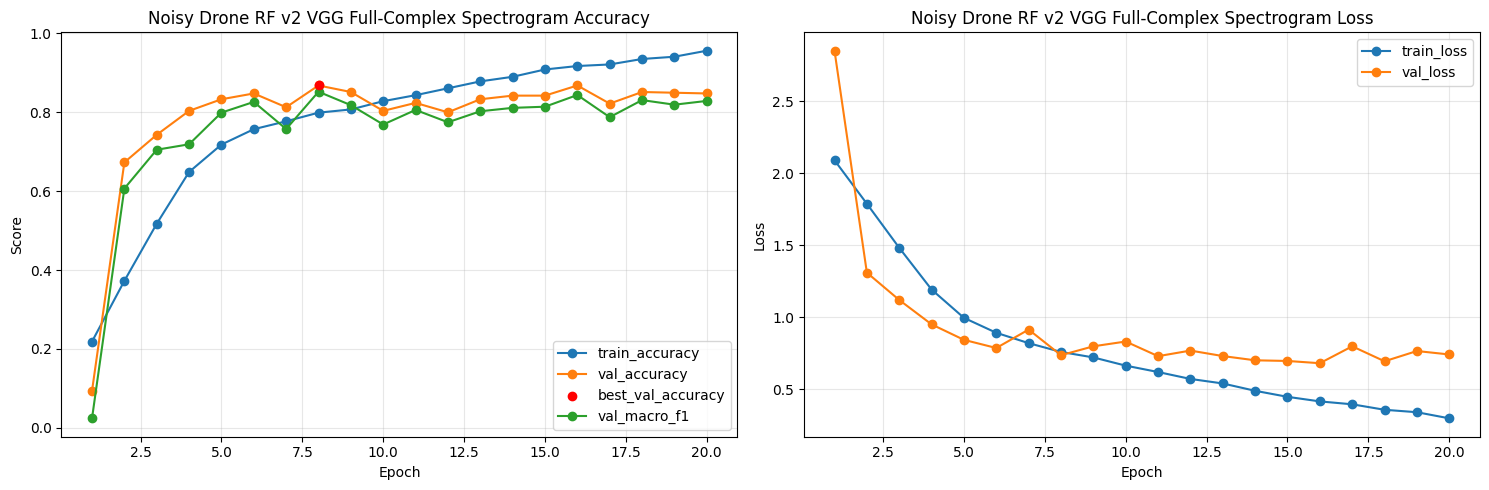

: 

In [ ]:
# Cell 5: Plot training curves if history artifacts are present
history_candidates = [
    model_dir / 'noisy_drone_rf_v2_vgg_full_complex_spectrogram_training_history.csv',
    model_dir / 'noisy_drone_rf_v2_vgg_complex_spectrogram_training_history.csv',
    outputs_dir / '33_noisy_drone_rf_v2_vgg_full_complex_spectrogram_training_history.csv',
]
history_csv_path = next((path for path in history_candidates if path.exists()), None)

if history_csv_path is None:
    print('No training-history CSV found; skipping training-curve plot.')
    print('Checked:')
    for path in history_candidates:
        print(' -', path)
else:
    history_df = pd.read_csv(history_csv_path)
    print('Loaded history:', history_csv_path)
    print('History rows:', len(history_df))
    if 'run_id' in history_df.columns:
        print('Runs:', history_df['run_id'].nunique())
        display(history_df.groupby('run_id').agg({'epoch': 'max', 'val_accuracy': 'max'}).tail(10))

    epoch_col = 'global_epoch' if 'global_epoch' in history_df.columns else 'epoch'
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    if 'accuracy' in history_df:
        axes[0].plot(history_df[epoch_col], history_df['accuracy'], marker='o', label='train_accuracy')
    if 'val_accuracy' in history_df:
        axes[0].plot(history_df[epoch_col], history_df['val_accuracy'], marker='o', label='val_accuracy')
        best_idx = history_df['val_accuracy'].idxmax()
        axes[0].scatter([history_df.loc[best_idx, epoch_col]], [history_df.loc[best_idx, 'val_accuracy']], color='red', zorder=5, label='best_val_accuracy')
    if 'val_macro_f1' in history_df:
        axes[0].plot(history_df[epoch_col], history_df['val_macro_f1'], marker='o', label='val_macro_f1')
    axes[0].set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Score')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    if 'loss' in history_df:
        axes[1].plot(history_df[epoch_col], history_df['loss'], marker='o', label='train_loss')
    if 'val_loss' in history_df:
        axes[1].plot(history_df[epoch_col], history_df['val_loss'], marker='o', label='val_loss')
    axes[1].set_title('Noisy Drone RF v2 VGG Full-Complex Spectrogram Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plot_path = outputs_dir / '44_noisy_drone_rf_v2_vgg_full_complex_training_curves.png'
    plt.savefig(plot_path, dpi=180)
    print('Saved:', plot_path)
    plt.show()
